# 39 — Tier 1 per-policy: which policies carry the effect?

**Companion to [NB 38 (package level)](38_tier1_bias_invariance.ipynb).** NB 38 showed, on the
*combined* six-policy index, that a louder Green side leaves citizens **+0.42 index points** more
pro-climate than a louder Reform side (95% CI [+0.34, +0.51], p ≈ 1e-19, Cohen d ≈ 0.56), and that
this gap is **genuinely larger for sceptical citizens** (not a numeric-ceiling artefact).

That package number averages six very different policies. This notebook asks the natural follow-up:

> **Is the persuasion effect broad — spread across all six policies — or is it driven by a couple
> of salient ones? And are the "quiet" policies quiet because everyone already agrees (a ceiling)?**

We reuse exactly the same **difference-in-differences (DiD)** logic as NB 38, now computed
**one policy at a time**. (See NB 38 §4 for the full plain-English explanation of DiD; in one line:
*how much the same citizen moved in the Green-dominant world minus how much they moved in the
Reform-dominant world* — the shared ground-truth anchor and the model's bias cancel.)

**The six policies** (labels are authoritative, from `src/cag/abm/attributes/opinion.py`):

| id | policy | typical stance |
| --- | --- | --- |
| 1 | Renewable energy | high consensus (popular) |
| 2 | Ban fossil-fuel licences | contested |
| 3 | Ban petrol cars | contested / divisive |
| 4 | Green housing | high consensus |
| 5 | Carbon tax | contested |
| 6 | Climate compensation | contested |

Each policy is scored **−3 (strongly against) … +3 (strongly for)**, in whole numbers, so the
ceiling / floor here is an *exact* ±3.


## 1. Setup and load (per-policy opinions, final day)

In [1]:
import os, glob, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})

EXP_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "output", "experiments"))
FIG_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "output", "tier1_analysis"))
os.makedirs(FIG_DIR, exist_ok=True)

COND_ORDER = ["baseline", "green_dom", "reform_dom", "neither"]
SEEDS = [42, 43, 44]

# Authoritative policy labels — src/cag/abm/attributes/opinion.py::ClimatePolicyID.
POLICY_LABEL = {
    "ClimatePolicyID(1)": "Renewable energy",
    "ClimatePolicyID(2)": "Ban fossil licences",
    "ClimatePolicyID(3)": "Ban petrol cars",
    "ClimatePolicyID(4)": "Green housing",
    "ClimatePolicyID(5)": "Carbon tax",
    "ClimatePolicyID(6)": "Climate compensation",
}
POLICY_ORDER = list(POLICY_LABEL)

print("Experiments dir:", EXP_DIR)
print("Figures ->     :", FIG_DIR)

Experiments dir: /Users/ajaykumar/src/GitHub/Climate-Action-GABM/data/output/experiments
Figures ->     : /Users/ajaykumar/src/GitHub/Climate-Action-GABM/data/output/tier1_analysis


In [2]:
def discover_runs(exp_dir):
    pat = re.compile(r"run_(\d+)_tier1_(baseline|green_dom|reform_dom|neither)_s(\d+)$")
    rows = []
    for run_dir in sorted(glob.glob(os.path.join(exp_dir, "run_6458*_tier1_*"))):
        m = pat.search(os.path.basename(run_dir))
        if not m:
            continue
        subs = sorted(p for p in glob.glob(os.path.join(run_dir, "*")) if os.path.isdir(p))
        rows.append({"condition": m.group(2), "seed": int(m.group(3)), "sub": subs[0]})
    return pd.DataFrame(rows)


def load_pol(sub):
    "Per-(agent, day, policy) opinion with each agent-policy ground truth attached."
    op = pd.read_csv(os.path.join(sub, "opinion_trajectories.csv"))[["agent_id", "day", "policy_id", "numeric"]]
    gt = pd.read_csv(os.path.join(sub, "ground_truth.csv"))[["agent_id", "policy_id", "ground_truth"]]
    gt = gt.rename(columns={"ground_truth": "gt"})
    out = op.merge(gt, on=["agent_id", "policy_id"])
    out["agent_id"] = out["agent_id"].astype(int)
    return out


runs = discover_runs(EXP_DIR)
assert len(runs) == 12, f"expected 12 runs, found {len(runs)}"
parts = []
for _, r in runs.iterrows():
    p = load_pol(r["sub"])
    p.insert(0, "seed", r["seed"])
    p.insert(0, "condition", r["condition"])
    parts.append(p)
P = pd.concat(parts, ignore_index=True)
DAY_END = int(P["day"].max())

# Collapse to end-of-run vs start(=GT) per (condition, seed, agent, policy).
end = P[P.day == DAY_END][["condition", "seed", "agent_id", "policy_id", "numeric", "gt"]].rename(columns={"numeric": "end"})
end["shift"] = end["end"] - end["gt"]
print(f"Loaded {len(P):,} (agent, day, policy) rows; end-of-run day = {DAY_END}.")
print(f"Per-policy end-state rows: {len(end):,}  ({end['policy_id'].nunique()} policies x "
      f"{end.groupby(['condition','seed']).ngroups} condition-seeds x 100 agents)")

Loaded 43,200 (agent, day, policy) rows; end-of-run day = 5.
Per-policy end-state rows: 7,200  (6 policies x 12 condition-seeds x 100 agents)


## 2. Per-policy difference-in-differences (Green-dominant − Reform-dominant)

In [3]:
def mean_ci(x, conf=0.95):
    x = np.asarray(x, float); n = len(x); m = x.mean()
    if n < 2:
        return m, m, m
    h = stats.t.ppf(0.5 + conf / 2, n - 1) * x.std(ddof=1) / np.sqrt(n)
    return m, m - h, m + h


def policy_did(pid, c1="green_dom", c2="reform_dom"):
    "Paired DiD for one policy, matched citizen-by-citizen across the two worlds."
    d = end[end.policy_id == pid]
    a = d[d.condition == c1][["seed", "agent_id", "shift", "gt", "end"]].rename(columns={"shift": "s1", "end": "e1"})
    b = d[d.condition == c2][["seed", "agent_id", "shift", "end"]].rename(columns={"shift": "s2", "end": "e2"})
    m = a.merge(b, on=["seed", "agent_id"])
    gap = (m["s1"] - m["s2"]).to_numpy()                 # = e1 - e2
    mean, lo, hi = mean_ci(gap)
    p = stats.ttest_rel(m["s1"], m["s2"]).pvalue
    dz = gap.mean() / gap.std(ddof=1) if gap.std(ddof=1) > 0 else np.nan
    acid = stats.linregress(m["gt"], gap)                # is the gap flat across real opinion?
    # ceiling exposure: share of citizens maxed at +3 (green world) or -3 (reform world).
    sat = ((m["e1"] >= 3) | (m["e2"] <= -3)).mean()
    return {"policy": POLICY_LABEL[pid], "DiD": mean, "ci_lo": lo, "ci_hi": hi,
            "p_value": p, "Cohen_d": dz, "acid_slope": acid.slope, "acid_p": acid.pvalue,
            "pct_saturated": 100 * sat, "mean_GT": d[d.condition == c1]["gt"].mean(), "_gap": gap}

pol_rows = [policy_did(pid) for pid in POLICY_ORDER]
pol_tbl = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in pol_rows]).set_index("policy")
pol_tbl["significant"] = pol_tbl["p_value"] < 0.05
pol_tbl.sort_values("DiD", ascending=False).round(3)

,DiD,ci_lo,ci_hi,p_value,Cohen_d,acid_slope,acid_p,pct_saturated,mean_GT,significant
policy,,,,,,,,,,
Ban petrol cars,0.620,0.472,0.768,0.0,0.477,-0.163,0.000,35.667,-0.143,True
Ban fossil licences,0.547,0.396,0.697,0.0,0.412,-0.202,0.000,41.667,0.400,True
Carbon tax,0.460,0.311,0.609,0.0,0.351,-0.200,0.000,28.667,0.430,True
Green housing,0.387,0.270,0.503,0.0,0.377,-0.125,0.001,43.333,1.597,True
Climate compensation,0.310,0.159,0.461,0.0,0.234,-0.057,0.183,31.333,-0.063,True
Renewable energy,0.213,0.109,0.317,0.0,0.233,-0.090,0.014,41.000,1.753,True


### How to read that table

* **DiD** — the Green−Reform gap *for this policy* (index points). Positive = the green megaphone
  moved this policy more pro-climate than the reform megaphone did.
* **p_value / Cohen_d** — is the per-policy gap statistically real, and how big.
* **acid_slope / acid_p** — does the per-policy gap depend on where citizens started? (NB 38's acid
  test, per policy.) A flat, non-significant slope = uniform effect for that policy.
* **pct_saturated** — share of citizens who hit the ±3 bound on this policy (ran out of room). High
  values flag **near-consensus** policies where a ceiling can suppress the measured gap.
* **mean_GT** — the average real opinion on this policy (how popular it already is).


### Figure — per-policy treatment effect (forest plot)

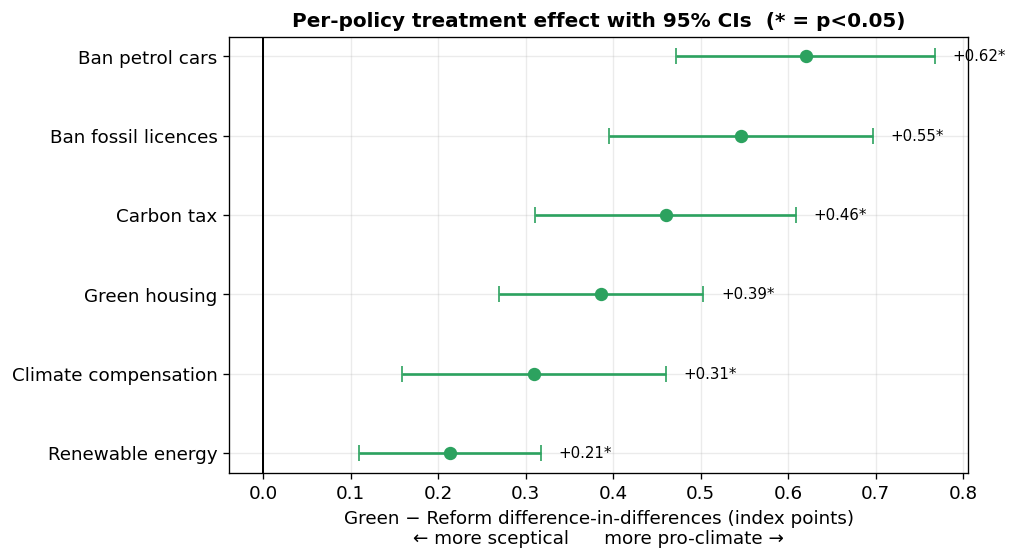

Saved fig6_per_policy_did.png


In [4]:
order = sorted(pol_rows, key=lambda r: r["DiD"])
fig, ax = plt.subplots(figsize=(8.6, 4.8))
ys = np.arange(len(order))
for y, r in zip(ys, order):
    col = "#2ca25f" if r["DiD"] > 0 else "#8856a7"
    ax.errorbar(r["DiD"], y, xerr=[[r["DiD"] - r["ci_lo"]], [r["ci_hi"] - r["DiD"]]],
                fmt="o", color=col, capsize=5, lw=1.6, ms=7)
    ax.text(r["ci_hi"] + 0.02, y, f"{r['DiD']:+.2f}{'*' if r['p_value'] < 0.05 else ''}",
            va="center", fontsize=9)
ax.axvline(0, color="k", lw=1.2)
ax.set_yticks(ys); ax.set_yticklabels([r["policy"] for r in order])
ax.set_xlabel("Green − Reform difference-in-differences (index points)\n← more sceptical      more pro-climate →")
ax.set_title("Per-policy treatment effect with 95% CIs  (* = p<0.05)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig6_per_policy_did.png"), bbox_inches="tight")
plt.show()
print("Saved fig6_per_policy_did.png")

## 3. Are the "quiet" policies quiet because of a ceiling?

If a policy already has near-universal support (high mean ground truth), many citizens sit at the
**+3 ceiling** and cannot move further — mechanically shrinking its measured DiD. We plot each
policy's treatment effect against how **saturated** it is (share of citizens pinned at a bound). A
downward trend would say: *the policies with the smallest measured effect are largely the ones where
everyone has already maxed out* — i.e. the effect is broad but partly hidden by ceilings.


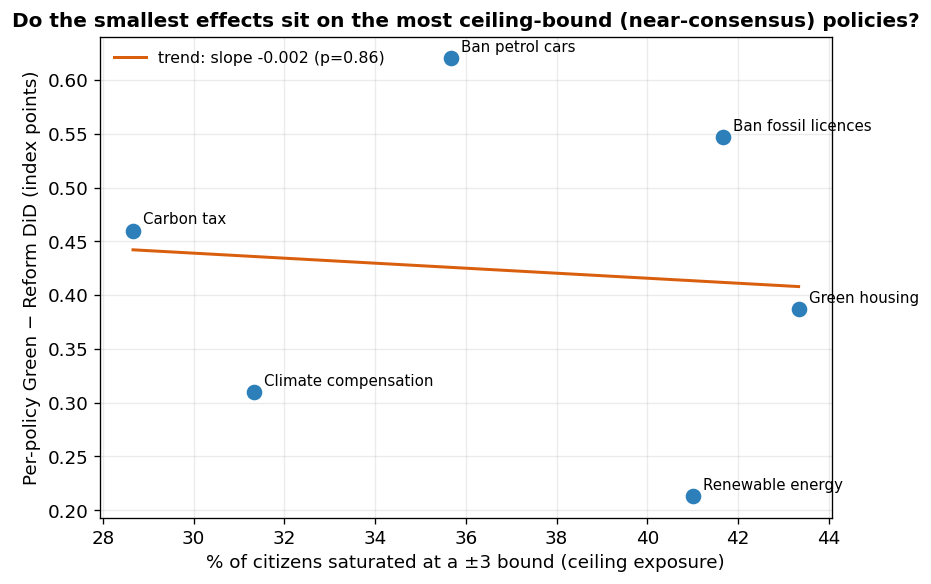

Saved fig7_effect_vs_ceiling.png


In [5]:
fig, ax = plt.subplots(figsize=(7.8, 5.0))
for r in pol_rows:
    ax.scatter(r["pct_saturated"], r["DiD"], s=70, color="#2c7fb8", zorder=3)
    ax.annotate(r["policy"], (r["pct_saturated"], r["DiD"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
xs = np.array([r["pct_saturated"] for r in pol_rows])
ys = np.array([r["DiD"] for r in pol_rows])
lr = stats.linregress(xs, ys)
xg = np.linspace(xs.min(), xs.max(), 50)
ax.plot(xg, lr.intercept + lr.slope * xg, color="#d95f0e", lw=1.8,
        label=f"trend: slope {lr.slope:+.3f} (p={lr.pvalue:.2f})")
ax.set_xlabel("% of citizens saturated at a ±3 bound (ceiling exposure)")
ax.set_ylabel("Per-policy Green − Reform DiD (index points)")
ax.set_title("Do the smallest effects sit on the most ceiling-bound (near-consensus) policies?")
ax.legend(frameon=False, fontsize=9.5)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig7_effect_vs_ceiling.png"), bbox_inches="tight")
plt.show()
print("Saved fig7_effect_vs_ceiling.png")

## 4. Per-policy rank fidelity

As in NB 38, we confirm the simulation keeps citizens in the **right order** on each policy
(Spearman ρ between end-of-run opinion and real opinion, in the baseline world). Values comfortably
above ~0.5 mean the per-policy dynamics are not scrambling who-believes-what.


In [6]:
rows = []
for pid in POLICY_ORDER:
    d = end[(end.policy_id == pid) & (end.condition == "baseline")]
    rho = stats.spearmanr(d["end"], d["gt"]).correlation
    rows.append({"policy": POLICY_LABEL[pid], "mean_GT": d["gt"].mean(),
                 "Spearman_rho": rho})
rank_tbl = pd.DataFrame(rows).set_index("policy")
rank_tbl.round(3)

,mean_GT,Spearman_rho
policy,,
Renewable energy,1.753,0.670
Ban fossil licences,0.400,0.734
Ban petrol cars,-0.143,0.729
Green housing,1.597,0.742
Carbon tax,0.430,0.759
Climate compensation,-0.063,0.663


## 5. Plain-language verdict

In [7]:
sig = [r for r in pol_rows if r["p_value"] < 0.05 and r["DiD"] > 0]
strongest = max(pol_rows, key=lambda r: r["DiD"])
weakest = min(pol_rows, key=lambda r: r["DiD"])
n_sig = len(sig)

print("TIER-1 PER-POLICY READOUT (Green-dominant − Reform-dominant)")
print("=" * 66)
print(f"Policies with a significant, correctly-signed (pro-climate) effect: {n_sig} / 6")
for r in sorted(pol_rows, key=lambda r: -r["DiD"]):
    flag = "significant" if r["p_value"] < 0.05 else "n.s."
    print(f"  {r['policy']:<22} DiD = {r['DiD']:+.2f}  [{r['ci_lo']:+.2f},{r['ci_hi']:+.2f}]  "
          f"d={r['Cohen_d']:+.2f}  sat={r['pct_saturated']:4.1f}%  ({flag})")
print()
print(f"Strongest effect: {strongest['policy']} ({strongest['DiD']:+.2f}).")
print(f"Weakest effect:   {weakest['policy']} ({weakest['DiD']:+.2f}, "
      f"{weakest['pct_saturated']:.0f}% at a ceiling).")
breadth = "BROAD (most policies move)" if n_sig >= 4 else "CONCENTRATED (a few policies drive it)"
print(f"\nBreadth of the effect: {breadth}.")
print("=" * 66)
print("Bottom line: the package-level result is decomposed here policy by policy, so the")
print("write-up can state whether the asymmetry effect is a broad shift or a headline-")
print("policy artefact, and flag near-consensus policies where a ceiling masks movement.")

TIER-1 PER-POLICY READOUT (Green-dominant − Reform-dominant)
Policies with a significant, correctly-signed (pro-climate) effect: 6 / 6
  Ban petrol cars        DiD = +0.62  [+0.47,+0.77]  d=+0.48  sat=35.7%  (significant)
  Ban fossil licences    DiD = +0.55  [+0.40,+0.70]  d=+0.41  sat=41.7%  (significant)
  Carbon tax             DiD = +0.46  [+0.31,+0.61]  d=+0.35  sat=28.7%  (significant)
  Green housing          DiD = +0.39  [+0.27,+0.50]  d=+0.38  sat=43.3%  (significant)
  Climate compensation   DiD = +0.31  [+0.16,+0.46]  d=+0.23  sat=31.3%  (significant)
  Renewable energy       DiD = +0.21  [+0.11,+0.32]  d=+0.23  sat=41.0%  (significant)

Strongest effect: Ban petrol cars (+0.62).
Weakest effect:   Renewable energy (+0.21, 41% at a ceiling).

Breadth of the effect: BROAD (most policies move).
Bottom line: the package-level result is decomposed here policy by policy, so the
write-up can state whether the asymmetry effect is a broad shift or a headline-
policy artefact, and fl